<h2 align="center">Healthcare Provider Fraud Detection System</h2>
<h3 align="center">Medicare Claims — ML Pipeline</h3>

---

## About This Project

The **US Government** pays doctors and hospitals (**providers**) for treating elderly/disabled patients under a program called **Medicare**.

Some **dishonest providers** cheat the system by:

| Fraud Type | Description |
|---|---|
| Fake Billing | Charging for treatments never given |
| Dead Patients | Billing for patients who already passed away |
| Upcoding | Patient came for checkup, billed for surgery |
| Duplicate Claims | Submitting the same bill multiple times |
| Ghost Patients | Inventing fake patients that don't exist |

> ### The US loses Billions every year to Medicare fraud!

---

## Our Job

Look at the billing history of **5,410 providers** and predict:

- Is this provider **LEGITIMATE**?
- Is this provider **COMMITTING FRAUD**?

---

## Dataset Overview

| # | File | Contains |
|---|---|---|
| 1 | `train_labels.csv` | Which providers are fraudulent — **Target** |
| 2 | `train_beneficiary.csv` | Patient demographics + chronic conditions |
| 3 | `train_inpatient.csv` | Bills for admitted/hospitalized patients |
| 4 | `train_outpatient.csv` | Bills for regular OPD visits |
| 5 | `test_labels.csv` | Provider IDs to predict on |
| 6 | `test_beneficiary.csv` | Test patients info |
| 7 | `test_inpatient.csv` | Test inpatient bills |
| 8 | `test_outpatient.csv` | Test outpatient bills |





In [1]:
# Data Handling
import pandas as pd
import numpy as np
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Handling Class Imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               StackingClassifier)
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score,
                              precision_score,
                              recall_score,
                              f1_score,
                              roc_auc_score,
                              confusion_matrix,
                              classification_report)

In [2]:
# STEP 1 — LOAD ALL 8 FILES

# Train Files
train_labels      = pd.read_csv('data/train_labels.csv')
train_beneficiary = pd.read_csv('data/train_beneficiary.csv')
train_inpatient   = pd.read_csv('data/train_inpatient.csv')
train_outpatient  = pd.read_csv('data/train_outpatient.csv')

# Test Files
test_labels       = pd.read_csv('data/test_labels.csv')
test_beneficiary  = pd.read_csv('data/test_beneficiary.csv')
test_inpatient    = pd.read_csv('data/test_inpatient.csv')
test_outpatient   = pd.read_csv('data/test_outpatient.csv')

files = {
    'train_labels'      : (train_labels,      'Provider IDs + Fraud Label (TARGET)'),
    'train_beneficiary' : (train_beneficiary, 'Patient demographics + chronic conditions'),
    'train_inpatient'   : (train_inpatient,   'Bills for admitted/hospitalized patients'),
    'train_outpatient'  : (train_outpatient,  'Bills for regular OPD/walk-in visits'),
    'test_labels'       : (test_labels,       'Provider IDs to predict on (no labels)'),
    'test_beneficiary'  : (test_beneficiary,  'Test patient demographics + conditions'),
    'test_inpatient'    : (test_inpatient,    'Test inpatient bills'),
    'test_outpatient'   : (test_outpatient,   'Test outpatient bills'),
}

print("STEP 1 — ALL 8 FILES LOADED")
print("─" * 72)
print(f"  {'File':<25} {'Rows':>10}   {'Cols':>5}   Description")
print("─" * 72)

total_rows = 0
total_cols = 0
for name, (df, desc) in files.items():
    total_rows += df.shape[0]
    total_cols += df.shape[1]
    print(f"  {name+'.csv':<25} {df.shape[0]:>10,}   {df.shape[1]:>5}   {desc}")

print("─" * 72)
print(f"  {'TOTAL':<25} {total_rows:>10,}   {total_cols:>5}")
print("─" * 72)

STEP 1 — ALL 8 FILES LOADED
────────────────────────────────────────────────────────────────────────
  File                            Rows    Cols   Description
────────────────────────────────────────────────────────────────────────
  train_labels.csv               5,410       2   Provider IDs + Fraud Label (TARGET)
  train_beneficiary.csv        138,556      25   Patient demographics + chronic conditions
  train_inpatient.csv           40,474      30   Bills for admitted/hospitalized patients
  train_outpatient.csv         517,737      27   Bills for regular OPD/walk-in visits
  test_labels.csv                1,353       1   Provider IDs to predict on (no labels)
  test_beneficiary.csv          63,968      25   Test patient demographics + conditions
  test_inpatient.csv             9,551      30   Test inpatient bills
  test_outpatient.csv          125,841      27   Test outpatient bills
────────────────────────────────────────────────────────────────────────
  TOTAL                

In [3]:
# STEP 2 — MERGE TRAIN FILES

# Action 1: Add claim type flag before stacking
train_inpatient['ClaimType']  = 'Inpatient'
train_outpatient['ClaimType'] = 'Outpatient'

# Action 2: Stack inpatient + outpatient into one claims table
all_claims = pd.concat([train_inpatient, train_outpatient], ignore_index=True)

# Action 3: Merge claims with beneficiary (add patient info to each claim)
all_claims = all_claims.merge(train_beneficiary, on='BeneID', how='left')

all_claims['DOB']          = pd.to_datetime(all_claims['DOB'])
all_claims['ClaimStartDt'] = pd.to_datetime(all_claims['ClaimStartDt'])
all_claims['patient_age']  = (all_claims['ClaimStartDt'] - all_claims['DOB']).dt.days / 365.25

# Action 4: Aggregate to provider level
provider_df = all_claims.groupby('Provider').agg(

    # Claim volume
    total_claims         = ('ClaimID', 'count'),
    inpatient_claims     = ('ClaimType', lambda x: (x == 'Inpatient').sum()),
    outpatient_claims    = ('ClaimType', lambda x: (x == 'Outpatient').sum()),

    # Money
    total_reimbursed     = ('InscClaimAmtReimbursed', 'sum'),
    avg_claim_amt        = ('InscClaimAmtReimbursed', 'mean'),
    max_claim_amt        = ('InscClaimAmtReimbursed', 'max'),
    std_claim_amt        = ('InscClaimAmtReimbursed', 'std'),
    total_deductible     = ('DeductibleAmtPaid', 'sum'),
    avg_deductible       = ('DeductibleAmtPaid', 'mean'),

    # Patients
    unique_patients      = ('BeneID', 'nunique'),
    avg_patient_age      = ('patient_age', 'mean'),
    deceased_patients    = ('DOD', lambda x: x.notna().sum()),

    # Physicians
    unique_physicians    = ('AttendingPhysician', 'nunique'), 
    unique_op_physicians = ('OperatingPhysician', 'nunique'),

    # Chronic conditions
    alzheimer_count      = ('ChronicCond_Alzheimer', 'sum'),
    diabetes_count       = ('ChronicCond_Diabetes', 'sum'),
    heartfailure_count   = ('ChronicCond_Heartfailure', 'sum'),
    kidney_count         = ('ChronicCond_KidneyDisease', 'sum'),
    cancer_count         = ('ChronicCond_Cancer', 'sum'),
    depression_count     = ('ChronicCond_Depression', 'sum'),

).reset_index()

# Action 5: Merge with fraud labels
provider_df = provider_df.merge(train_labels, on='Provider', how='left')

# Action 6: Encode target
provider_df['PotentialFraud'] = provider_df['PotentialFraud'].map({'Yes': 1, 'No': 0})

# ── Display merging journey ──
print("STEP 2 — MERGING JOURNEY (TRAIN FILES)")
print("─" * 65)
print(f"  Inpatient rows                   : {train_inpatient.shape[0]:>10,}")
print(f"  Outpatient rows                  : {train_outpatient.shape[0]:>10,}")
print(f"  After stacking (combined claims) : {all_claims.shape[0]:>10,}  <- ACTION 1")
print("─" * 65)
print(f"  Before merging beneficiary       : {all_claims.shape[1]-1:>10}  cols")
print(f"  After merging beneficiary        : {all_claims.shape[1]:>10}  cols  <- ACTION 2")
print("─" * 65)
print(f"  Before aggregation               : {all_claims.shape[0]:>10,}  rows (claim level)")
print(f"  After aggregation                : {provider_df.shape[0]:>10,}  rows (provider level)  <- ACTION 3")
print(f"  Columns after aggregation        : {provider_df.shape[1]:>10}")
print("─" * 65)
print(f"""
  WHY IS THIS STILL RICH DATA?
  ─────────────────────────────────────────────────────────────
  {all_claims.shape[0]:,} claims compressed into {provider_df.shape[0]:,} provider rows

  Average claims per provider      : {provider_df['total_claims'].mean():>10.0f}
  Average patients per provider    : {provider_df['unique_patients'].mean():>10.0f}
  Average billing per provider     : ${provider_df['total_reimbursed'].mean():>10,.0f}
  Max claims by one provider       : {provider_df['total_claims'].max():>10,.0f}
  Total money in this dataset      : ${provider_df['total_reimbursed'].sum():>10,.0f}

  Each row = entire billing history of 1 provider
  Not just 1 data point — it summarizes hundreds
  of claims and dozens of patients intelligently
""")
print("─" * 65)

STEP 2 — MERGING JOURNEY (TRAIN FILES)
─────────────────────────────────────────────────────────────────
  Inpatient rows                   :     40,474
  Outpatient rows                  :    517,737
  After stacking (combined claims) :    558,211  <- ACTION 1
─────────────────────────────────────────────────────────────────
  Before merging beneficiary       :         55  cols
  After merging beneficiary        :         56  cols  <- ACTION 2
─────────────────────────────────────────────────────────────────
  Before aggregation               :    558,211  rows (claim level)
  After aggregation                :      5,410  rows (provider level)  <- ACTION 3
  Columns after aggregation        :         22
─────────────────────────────────────────────────────────────────

  WHY IS THIS STILL RICH DATA?
  ─────────────────────────────────────────────────────────────
  558,211 claims compressed into 5,410 provider rows

  Average claims per provider      :        103
  Average patients pe

In [4]:
# STEP 3 — FEATURE ENGINEERING

# Count BEFORE adding anything
feature_cols = [
    'claims_per_patient', 'reimbursed_per_claim', 'reimbursed_per_patient',
    'deductible_ratio', 'inpat_outpat_ratio', 'physician_per_patient',
    'deceased_billed_flag', 'high_claim_flag', 'high_claims_per_patient',
    'many_physicians_flag', 'chronic_condition_score', 'claim_variability',
    'deceased_patient_ratio'
]


provider_df.drop(columns=[c for c in feature_cols if c in provider_df.columns], inplace=True)

cols_before = provider_df.shape[1]

# Ratio Features
provider_df['claims_per_patient']        = provider_df['total_claims']      / (provider_df['unique_patients'] + 1)
provider_df['reimbursed_per_claim']      = provider_df['total_reimbursed']  / (provider_df['total_claims'] + 1)
provider_df['reimbursed_per_patient']    = provider_df['total_reimbursed']  / (provider_df['unique_patients'] + 1)
provider_df['deductible_ratio']          = provider_df['total_deductible']  / (provider_df['total_reimbursed'] + 1)
provider_df['inpat_outpat_ratio']        = provider_df['inpatient_claims']  / (provider_df['outpatient_claims'] + 1)
provider_df['physician_per_patient']     = provider_df['unique_physicians'] / (provider_df['unique_patients'] + 1)

# Risk Flag Features
provider_df['deceased_billed_flag']      = (provider_df['deceased_patients'] > 0).astype(int)
provider_df['high_claim_flag']           = (provider_df['avg_claim_amt'] > provider_df['avg_claim_amt'].quantile(0.90)).astype(int)
provider_df['high_claims_per_patient']   = (provider_df['claims_per_patient'] > provider_df['claims_per_patient'].quantile(0.90)).astype(int)
provider_df['many_physicians_flag']      = (provider_df['unique_physicians'] > provider_df['unique_physicians'].quantile(0.90)).astype(int)

# Chronic Condition Score
provider_df['chronic_condition_score']   = (provider_df['alzheimer_count']    +
                                             provider_df['diabetes_count']     +
                                             provider_df['heartfailure_count'] +
                                             provider_df['kidney_count']       +
                                             provider_df['cancer_count']       +
                                             provider_df['depression_count'])

# Claim Variability
provider_df['claim_variability']         = provider_df['std_claim_amt'] / (provider_df['avg_claim_amt'] + 1)

# Deceased to total patient ratio
provider_df['deceased_patient_ratio']    = provider_df['deceased_patients'] / (provider_df['unique_patients'] + 1)

cols_after  = provider_df.shape[1]
cols_new    = cols_after - cols_before

print("STEP 3 — FEATURE ENGINEERING")
print("─" * 60)
print(f"  Columns before engineering  : {cols_before}")
print(f"  New features created        : {cols_new}")
print(f"  Columns after engineering   : {cols_after}")
print("─" * 60)
print(f"""
  6 Ratio Features     : claims_per_patient, reimbursed_per_claim,
                         reimbursed_per_patient, deductible_ratio,
                         inpat_outpat_ratio, physician_per_patient

  4 Risk Flag Features : deceased_billed_flag, high_claim_flag,
                         high_claims_per_patient, many_physicians_flag

  3 Composite Features : chronic_condition_score,
                         claim_variability,
                         deceased_patient_ratio
""")
print("─" * 60)

STEP 3 — FEATURE ENGINEERING
────────────────────────────────────────────────────────────
  Columns before engineering  : 22
  New features created        : 13
  Columns after engineering   : 35
────────────────────────────────────────────────────────────

  6 Ratio Features     : claims_per_patient, reimbursed_per_claim,
                         reimbursed_per_patient, deductible_ratio,
                         inpat_outpat_ratio, physician_per_patient

  4 Risk Flag Features : deceased_billed_flag, high_claim_flag,
                         high_claims_per_patient, many_physicians_flag

  3 Composite Features : chronic_condition_score,
                         claim_variability,
                         deceased_patient_ratio

────────────────────────────────────────────────────────────


In [5]:
# STEP 4 — PREPROCESSING

X = provider_df.drop(columns=['Provider', 'PotentialFraud'])
y = provider_df['PotentialFraud']

X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

# Drop rows where target is null
provider_df.dropna(subset=['PotentialFraud'], inplace=True)
X = X.loc[provider_df.index]
y = y.loc[provider_df.index]

feature_names = X.columns.tolist()

# STEP 5 — TRAIN VALIDATION SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("STEP 4 & 5 — PREPROCESSING & TRAIN VALIDATION SPLIT")
print("─" * 55)
print(f"  Total samples      : {X.shape[0]:,}")
print(f"  Total features     : {X.shape[1]}")
print(f"  Training samples   : {X_train.shape[0]:,}  (80%)")
print(f"  Validation samples : {X_val.shape[0]:,}  (20%)")
print(f"  Fraud cases        : {y.sum():,}  ({y.mean()*100:.1f}%)")
print(f"  Legit cases        : {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)")
print("─" * 55)

STEP 4 & 5 — PREPROCESSING & TRAIN VALIDATION SPLIT
───────────────────────────────────────────────────────
  Total samples      : 5,410
  Total features     : 33
  Training samples   : 4,328  (80%)
  Validation samples : 1,082  (20%)
  Fraud cases        : 506  (9.4%)
  Legit cases        : 4,904  (90.6%)
───────────────────────────────────────────────────────


In [6]:
# STEP 6 — SCALING

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Save scaler for test data later
os.makedirs('models', exist_ok=True)
pickle.dump(scaler, open('models/scaler.pkl', 'wb'))

In [7]:
# STEP 7 — SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("STEP 7 — SMOTE (HANDLING CLASS IMBALANCE)")
print("─" * 50)
print(f"  Before SMOTE:")
print(f"    Legitimate : {(y_train == 0).sum():,}  ({(y_train == 0).mean()*100:.1f}%)")
print(f"    Fraudulent : {(y_train == 1).sum():,}  ({(y_train == 1).mean()*100:.1f}%)")
print(f"    Ratio      : {(y_train == 0).sum() / (y_train == 1).sum():.1f} : 1")
print()
print(f"  After SMOTE:")
print(f"    Legitimate : {(y_train_balanced == 0).sum():,}  (50.0%)")
print(f"    Fraudulent : {(y_train_balanced == 1).sum():,}  (50.0%)")
print(f"    Ratio      : 1.0 : 1  (Balanced)")
print("─" * 50)

STEP 7 — SMOTE (HANDLING CLASS IMBALANCE)
──────────────────────────────────────────────────
  Before SMOTE:
    Legitimate : 3,923  (90.6%)
    Fraudulent : 405  (9.4%)
    Ratio      : 9.7 : 1

  After SMOTE:
    Legitimate : 3,923  (50.0%)
    Fraudulent : 3,923  (50.0%)
    Ratio      : 1.0 : 1  (Balanced)
──────────────────────────────────────────────────


In [8]:
# STEP 8 — PRE TRAINING CHECKS

print("STEP 8 — PRE TRAINING CHECKS")
print("─" * 55)

# Check 1 — Missing values in X_train_balanced
null_count = pd.DataFrame(X_train_balanced).isnull().sum().sum()
print(f"  Missing values in X_train_balanced : {null_count}")

# Check 2 — Missing values in X_val_scaled
null_val = pd.DataFrame(X_val_scaled).isnull().sum().sum()
print(f"  Missing values in X_val_scaled     : {null_val}")

# Check 3 — Missing values in y_train_balanced
print(f"  Missing values in y_train_balanced : {pd.Series(y_train_balanced).isnull().sum()}")

# Check 4 — Missing values in y_val
print(f"  Missing values in y_val            : {y_val.isnull().sum()}")

# Check 5 — Shape check
print()
print(f"  X_train_balanced shape : {X_train_balanced.shape}")
print(f"  y_train_balanced shape : {y_train_balanced.shape}")
print(f"  X_val_scaled shape     : {X_val_scaled.shape}")
print(f"  y_val shape            : {y_val.shape}")

# Check 6 — Infinite values
inf_count = np.isinf(X_train_balanced).sum().sum()
print()
print(f"  Infinite values in X_train_balanced : {inf_count}")

# Fix infinite values if any
if inf_count > 0:
    X_train_balanced = np.nan_to_num(X_train_balanced, nan=0.0, posinf=0.0, neginf=0.0)
    X_val_scaled     = np.nan_to_num(X_val_scaled,     nan=0.0, posinf=0.0, neginf=0.0)
    print("  Infinite values fixed!")

# Check 7 — Target distribution
print()
print(f"  y_train_balanced distribution:")
print(f"    Legitimate : {(y_train_balanced == 0).sum():,}")
print(f"    Fraudulent : {(y_train_balanced == 1).sum():,}")
print()
print(f"  y_val distribution:")
print(f"    Legitimate : {(y_val == 0).sum():,}")
print(f"    Fraudulent : {(y_val == 1).sum():,}")

print("─" * 55)

# Final verdict
if null_count == 0 and null_val == 0 and inf_count == 0:
    print("  All checks passed — Ready to train!")
else:
    print("  Issues found — fixed automatically above")

print("─" * 55)

STEP 8 — PRE TRAINING CHECKS
───────────────────────────────────────────────────────
  Missing values in X_train_balanced : 0
  Missing values in X_val_scaled     : 0
  Missing values in y_train_balanced : 0
  Missing values in y_val            : 0

  X_train_balanced shape : (7846, 33)
  y_train_balanced shape : (7846,)
  X_val_scaled shape     : (1082, 33)
  y_val shape            : (1082,)

  Infinite values in X_train_balanced : 0

  y_train_balanced distribution:
    Legitimate : 3,923
    Fraudulent : 3,923

  y_val distribution:
    Legitimate : 981
    Fraudulent : 101
───────────────────────────────────────────────────────
  All checks passed — Ready to train!
───────────────────────────────────────────────────────


In [9]:
# STEP 8b — 5-FOLD STRATIFIED CROSS VALIDATION

from imblearn.pipeline import Pipeline as ImbPipeline

cv_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss'),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("STEP 8b — 5-FOLD STRATIFIED CROSS VALIDATION")
print("─" * 60)
print(f"  {'Model':<22} {'Mean F1':>10} {'Std F1':>10}")
print("─" * 60)

cv_results = {}
for name, model in cv_models.items():
    # Scale + SMOTE inside each fold to avoid data leakage
    pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<22} {scores.mean():>10.4f} {scores.std():>10.4f}")

print("─" * 60)
print("  (Consistent scores across folds = model isn't just lucky on one split)")

STEP 8b — 5-FOLD STRATIFIED CROSS VALIDATION
────────────────────────────────────────────────────────────
  Model                     Mean F1     Std F1
────────────────────────────────────────────────────────────
  Logistic Regression        0.5526     0.0096
  Random Forest              0.6065     0.0075
  XGBoost                    0.5721     0.0145
────────────────────────────────────────────────────────────
  (Consistent scores across folds = model isn't just lucky on one split)


In [10]:
# STEP 9 — TRAIN MODELS

base_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'XGBoost'             : XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss'),
}

stacking_model = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')),
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

trained_models = {}

print("STEP 9 — TRAINING MODELS")
print("─" * 50)

for name, model in base_models.items():
    print(f"  Training {name}...", end=' ')
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    print("Done")

print(f"  Training Stacking Classifier...", end=' ')
stacking_model.fit(X_train_balanced, y_train_balanced)
trained_models['Stacking Classifier'] = stacking_model
print("Done")

print("─" * 50)
print(f"  Total models trained : {len(trained_models)}")
print("─" * 50)

os.makedirs('models', exist_ok=True)
for name, model in trained_models.items():
    filename = name.lower().replace(' ', '_')
    pickle.dump(model, open(f'models/{filename}.pkl', 'wb'))

pickle.dump(feature_names, open('models/feature_names.pkl', 'wb'))
print("  All models saved to models/ folder")
print("─" * 50)

STEP 9 — TRAINING MODELS
──────────────────────────────────────────────────
  Training Logistic Regression... Done
  Training Random Forest... Done
  Training XGBoost... Done
  Training Stacking Classifier... Done
──────────────────────────────────────────────────
  Total models trained : 4
──────────────────────────────────────────────────
  All models saved to models/ folder
──────────────────────────────────────────────────


In [11]:
# STEP 10 — EVALUATE MODELS

results = []

for name, model in trained_models.items():
    y_pred       = model.predict(X_val_scaled)
    y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

    results.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_val, y_pred),
        'Precision' : precision_score(y_val, y_pred),
        'Recall'    : recall_score(y_val, y_pred),
        'F1'        : f1_score(y_val, y_pred),
        'ROC AUC'   : roc_auc_score(y_val, y_pred_proba),
    })

results_df = results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)

print("STEP 10 — MODEL EVALUATION RESULTS")
print("─" * 75)
print(f"  {'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC AUC':>9}")
print("─" * 75)

for _, row in results_df.iterrows():
    best = row['Model'] == results_df.iloc[0]['Model']
    tag  = '  <- Best' if best else ''
    print(f"  {row['Model']:<25} {row['Accuracy']:>9.4f} {row['Precision']:>10.4f} {row['Recall']:>8.4f} {row['F1']:>8.4f} {row['ROC AUC']:>9.4f}{tag}")

print("─" * 75)

# Save best model separately
best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]
pickle.dump(best_model, open('models/best_model.pkl', 'wb'))

print(f"  Best Model : {best_model_name}")
print(f"  Saved to   : models/best_model.pkl")
print("─" * 75)

STEP 10 — MODEL EVALUATION RESULTS
───────────────────────────────────────────────────────────────────────────
  Model                      Accuracy  Precision   Recall       F1   ROC AUC
───────────────────────────────────────────────────────────────────────────
  Stacking Classifier          0.9233     0.5763   0.6733   0.6210    0.9467  <- Best
  XGBoost                      0.9039     0.4912   0.8317   0.6176    0.9513
  Random Forest                0.9076     0.5032   0.7822   0.6124    0.9444
  Logistic Regression          0.8734     0.4182   0.9109   0.5732    0.9512
───────────────────────────────────────────────────────────────────────────
  Best Model : Stacking Classifier
  Saved to   : models/best_model.pkl
───────────────────────────────────────────────────────────────────────────


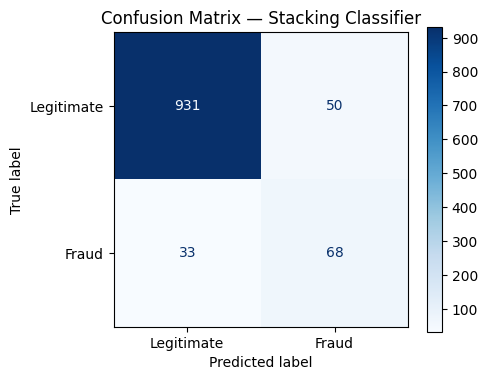

True Negatives  (correctly caught legit)  : 931
False Positives (wrongly flagged fraud)    : 50
False Negatives (missed fraud — costly!)   : 33
True Positives  (correctly caught fraud)   : 68


In [12]:
# STEP 10b — CONFUSION MATRIX (BEST MODEL)

from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_val_scaled)
cm = confusion_matrix(y_val, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly caught legit)  : {tn}")
print(f"False Positives (wrongly flagged fraud)    : {fp}")
print(f"False Negatives (missed fraud — costly!)   : {fn}")
print(f"True Positives  (correctly caught fraud)   : {tp}")

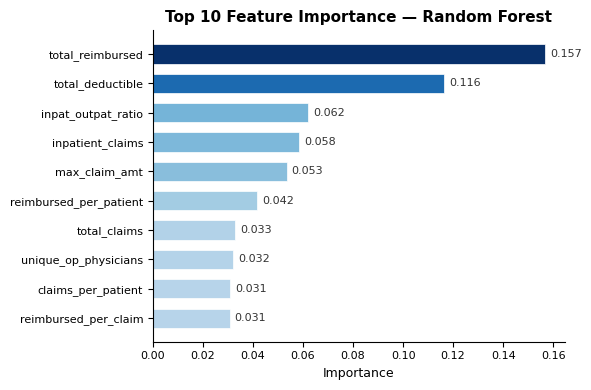

Top 10 Features Driving Fraud Predictions:
─────────────────────────────────────────────
  1. total_reimbursed             0.1568
  2. total_deductible             0.1163
  3. inpat_outpat_ratio           0.0620
  4. inpatient_claims             0.0584
  5. max_claim_amt                0.0534
  6. reimbursed_per_patient       0.0416
  7. total_claims                 0.0330
  8. unique_op_physicians         0.0319
  9. claims_per_patient           0.0308
  10. reimbursed_per_claim         0.0307


In [13]:
# STEP 10c — FEATURE IMPORTANCE (GRADIENT SHADED, COMPACT)

import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Use Random Forest (tree-based models give importance directly)
importances = trained_models['Random Forest'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top10 = feat_imp_df.head(10).iloc[::-1]  # reversed so most important is on top of barh

# Map importance -> color shade (darker = more important)
norm = mcolors.Normalize(vmin=top10['Importance'].min(), vmax=top10['Importance'].max())
colors = cm.Blues(norm(top10['Importance']) * 0.7 + 0.3)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(top10['Feature'], top10['Importance'], color=colors, edgecolor='white', linewidth=0.5, height=0.65)

for bar, val in zip(bars, top10['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=8, color='#333333')

ax.set_title('Top 10 Feature Importance — Random Forest', fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=9)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("Top 10 Features Driving Fraud Predictions:")
print("─" * 45)
for i, row in feat_imp_df.head(10).iterrows():
    print(f"  {i+1}. {row['Feature']:<28} {row['Importance']:.4f}")

STEP 10d — THRESHOLD OPTIMIZATION
───────────────────────────────────────────────────────
  Default threshold (0.5):
    Precision : 0.5763
    Recall    : 0.6733
    F1        : 0.6210

  Optimal threshold (0.445):
    Precision : 0.5827
    Recall    : 0.7327
    F1        : 0.6491
───────────────────────────────────────────────────────


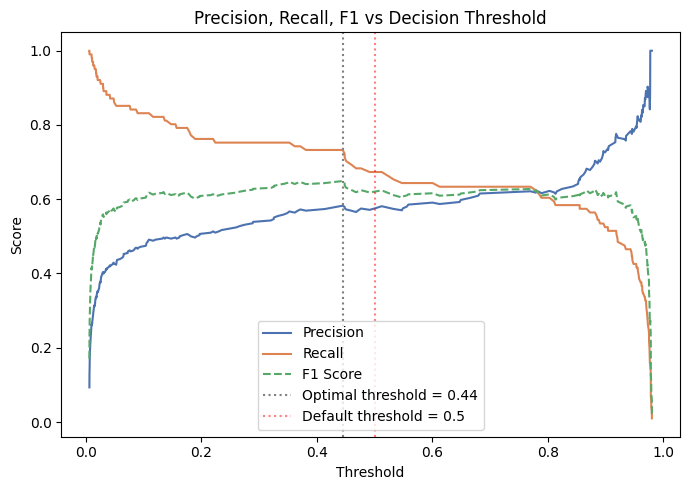

In [14]:
# STEP 10d — THRESHOLD OPTIMIZATION

from sklearn.metrics import precision_recall_curve

y_proba = best_model.predict_proba(X_val_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print("STEP 10d — THRESHOLD OPTIMIZATION")
print("─" * 55)
print(f"  Default threshold (0.5):")
y_pred_default = (y_proba >= 0.5).astype(int)
print(f"    Precision : {precision_score(y_val, y_pred_default):.4f}")
print(f"    Recall    : {recall_score(y_val, y_pred_default):.4f}")
print(f"    F1        : {f1_score(y_val, y_pred_default):.4f}")
print()
print(f"  Optimal threshold ({best_threshold:.3f}):")
y_pred_optimal = (y_proba >= best_threshold).astype(int)
print(f"    Precision : {precision_score(y_val, y_pred_optimal):.4f}")
print(f"    Recall    : {recall_score(y_val, y_pred_optimal):.4f}")
print(f"    F1        : {f1_score(y_val, y_pred_optimal):.4f}")
print("─" * 55)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='#4C72B0')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#DD8452')
plt.plot(thresholds, f1_scores, label='F1 Score', color='#55A868', linestyle='--')
plt.axvline(best_threshold, color='gray', linestyle=':', label=f'Optimal threshold = {best_threshold:.2f}')
plt.axvline(0.5, color='red', linestyle=':', alpha=0.5, label='Default threshold = 0.5')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# STEP 11 — MERGE TEST FILES

test_inpatient['ClaimType']  = 'Inpatient'
test_outpatient['ClaimType'] = 'Outpatient'

test_claims = pd.concat([test_inpatient, test_outpatient], ignore_index=True)
test_claims = test_claims.merge(test_beneficiary, on='BeneID', how='left')

test_claims['DOB']          = pd.to_datetime(test_claims['DOB'])
test_claims['ClaimStartDt'] = pd.to_datetime(test_claims['ClaimStartDt'])
test_claims['patient_age']  = (test_claims['ClaimStartDt'] - test_claims['DOB']).dt.days / 365.25

test_provider_df = test_claims.groupby('Provider').agg(

    # Claim volume
    total_claims         = ('ClaimID', 'count'),
    inpatient_claims     = ('ClaimType', lambda x: (x == 'Inpatient').sum()),
    outpatient_claims    = ('ClaimType', lambda x: (x == 'Outpatient').sum()),

    # Money
    total_reimbursed     = ('InscClaimAmtReimbursed', 'sum'),
    avg_claim_amt        = ('InscClaimAmtReimbursed', 'mean'),
    max_claim_amt        = ('InscClaimAmtReimbursed', 'max'),
    std_claim_amt        = ('InscClaimAmtReimbursed', 'std'),
    total_deductible     = ('DeductibleAmtPaid', 'sum'),
    avg_deductible       = ('DeductibleAmtPaid', 'mean'),

    # Patients
    unique_patients      = ('BeneID', 'nunique'),
    avg_patient_age      = ('patient_age', 'mean'),
    deceased_patients    = ('DOD', lambda x: x.notna().sum()),

    # Physicians
    unique_physicians    = ('AttendingPhysician', 'nunique'),
    unique_op_physicians = ('OperatingPhysician', 'nunique'),

    # Chronic conditions
    alzheimer_count      = ('ChronicCond_Alzheimer', 'sum'),
    diabetes_count       = ('ChronicCond_Diabetes', 'sum'),
    heartfailure_count   = ('ChronicCond_Heartfailure', 'sum'),
    kidney_count         = ('ChronicCond_KidneyDisease', 'sum'),
    cancer_count         = ('ChronicCond_Cancer', 'sum'),
    depression_count     = ('ChronicCond_Depression', 'sum'),

).reset_index()

print("STEP 11 — MERGE TEST FILES")
print("─" * 55)
print(f"  Test Inpatient rows          : {test_inpatient.shape[0]:,}")
print(f"  Test Outpatient rows         : {test_outpatient.shape[0]:,}")
print(f"  After stacking               : {test_claims.shape[0]:,}")
print(f"  After merging beneficiary    : {test_claims.shape[1]} cols")
print(f"  After aggregation            : {test_provider_df.shape[0]:,} providers")
print("─" * 55)

STEP 11 — MERGE TEST FILES
───────────────────────────────────────────────────────
  Test Inpatient rows          : 9,551
  Test Outpatient rows         : 125,841
  After stacking               : 135,392
  After merging beneficiary    : 56 cols
  After aggregation            : 1,353 providers
───────────────────────────────────────────────────────


In [16]:
# STEP 12 — FEATURE ENGINEERING ON TEST DATA

test_provider_df['claims_per_patient']        = test_provider_df['total_claims']      / (test_provider_df['unique_patients'] + 1)
test_provider_df['reimbursed_per_claim']      = test_provider_df['total_reimbursed']  / (test_provider_df['total_claims'] + 1)
test_provider_df['reimbursed_per_patient']    = test_provider_df['total_reimbursed']  / (test_provider_df['unique_patients'] + 1)
test_provider_df['deductible_ratio']          = test_provider_df['total_deductible']  / (test_provider_df['total_reimbursed'] + 1)
test_provider_df['inpat_outpat_ratio']        = test_provider_df['inpatient_claims']  / (test_provider_df['outpatient_claims'] + 1)
test_provider_df['physician_per_patient']     = test_provider_df['unique_physicians'] / (test_provider_df['unique_patients'] + 1)

test_provider_df['deceased_billed_flag']      = (test_provider_df['deceased_patients'] > 0).astype(int)
test_provider_df['high_claim_flag']           = (test_provider_df['avg_claim_amt'] > test_provider_df['avg_claim_amt'].quantile(0.90)).astype(int)
test_provider_df['high_claims_per_patient']   = (test_provider_df['claims_per_patient'] > test_provider_df['claims_per_patient'].quantile(0.90)).astype(int)
test_provider_df['many_physicians_flag']      = (test_provider_df['unique_physicians'] > test_provider_df['unique_physicians'].quantile(0.90)).astype(int)

test_provider_df['chronic_condition_score']   = (test_provider_df['alzheimer_count']    +
                                                  test_provider_df['diabetes_count']     +
                                                  test_provider_df['heartfailure_count'] +
                                                  test_provider_df['kidney_count']       +
                                                  test_provider_df['cancer_count']       +
                                                  test_provider_df['depression_count'])

test_provider_df['claim_variability']         = test_provider_df['std_claim_amt'] / (test_provider_df['avg_claim_amt'] + 1)
test_provider_df['deceased_patient_ratio']    = test_provider_df['deceased_patients'] / (test_provider_df['unique_patients'] + 1)

# Align test columns with train feature names
X_test = test_provider_df[feature_names]
X_test = X_test.fillna(X_test.median())
X_test_scaled = scaler.transform(X_test)

STEP 13 — FRAUD PREDICTION RESULTS
────────────────────────────────────────────────────────────
  Decision threshold used    : 0.445  (optimized, not default 0.5)
  Total providers predicted  : 1,353
  Predicted Fraudulent       : 143  (10.6%)
  Predicted Legitimate       : 1,210  (89.4%)
  Best model used            : Stacking Classifier
  Results saved to           : results/fraud_predictions.csv
────────────────────────────────────────────────────────────


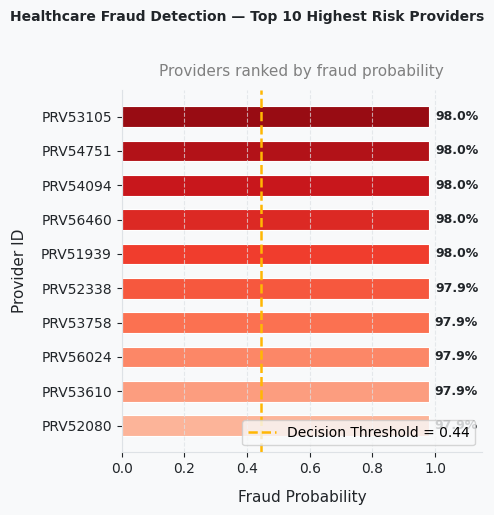

In [23]:
# STEP 13 — PREDICT + SAVE RESULTS (USING OPTIMIZED THRESHOLD)

probabilities = best_model.predict_proba(X_test_scaled)[:, 1]
predictions   = (probabilities >= best_threshold).astype(int)

results_final = pd.DataFrame({
    'Provider'          : test_provider_df['Provider'].values,
    'Fraud_Probability' : probabilities,
    'Prediction'        : ['Fraud' if p == 1 else 'Legitimate' for p in predictions]
}).sort_values('Fraud_Probability', ascending=False).reset_index(drop=True)

os.makedirs('results', exist_ok=True)
results_final.to_csv('results/fraud_predictions.csv', index=False)

fraud_count = (predictions == 1).sum()
legit_count = (predictions == 0).sum()

print("STEP 13 — FRAUD PREDICTION RESULTS")
print("─" * 60)
print(f"  Decision threshold used    : {best_threshold:.3f}  (optimized, not default 0.5)")
print(f"  Total providers predicted  : {len(predictions):,}")
print(f"  Predicted Fraudulent       : {fraud_count:,}  ({fraud_count/len(predictions)*100:.1f}%)")
print(f"  Predicted Legitimate       : {legit_count:,}  ({legit_count/len(predictions)*100:.1f}%)")
print(f"  Best model used            : {best_model_name}")
print(f"  Results saved to           : results/fraud_predictions.csv")
print("─" * 60)

# ── PALETTE ──────────────────────────────────────────────
BG_COLOR     = '#F8F9FA'
GRID_COLOR   = '#DEE2E6'
TEXT_COLOR   = '#212529'
ACCENT_COLOR = '#FFB703'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.facecolor'   : BG_COLOR,
    'figure.facecolor' : BG_COLOR,
    'axes.edgecolor'   : GRID_COLOR,
    'axes.labelcolor'  : TEXT_COLOR,
    'xtick.color'      : TEXT_COLOR,
    'ytick.color'      : TEXT_COLOR,
    'grid.color'       : GRID_COLOR,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
})

# ── Graph: Top 10 Highest Risk Providers ─────────────────
top10 = results_final.head(10)

# Gradient — darkest for highest risk, lightest for lowest
import matplotlib.colors as mcolors
cmap   = plt.cm.Reds
colors = [cmap(0.9 - i * 0.07) for i in range(len(top10))]

fig, ax = plt.subplots(figsize=(5, 5))
fig.suptitle(
    'Healthcare Fraud Detection — Top 10 Highest Risk Providers',
    fontsize=10, fontweight='bold', color=TEXT_COLOR, y=1.02
)

bars = ax.barh(
    top10['Provider'].astype(str),
    top10['Fraud_Probability'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    height=0.6
)

ax.invert_yaxis()
ax.set_title('Providers ranked by fraud probability',
              fontsize=11, color='grey', pad=10)
ax.set_xlabel('Fraud Probability', fontsize=11, color=TEXT_COLOR, labelpad=10)
ax.set_ylabel('Provider ID',       fontsize=11, color=TEXT_COLOR, labelpad=10)
ax.set_xlim(0, 1.15)
ax.axvline(best_threshold, color=ACCENT_COLOR, linestyle='--',
           linewidth=1.8, label=f'Decision Threshold = {best_threshold:.2f}')
ax.grid(axis='x')

for bar, prob in zip(bars, top10['Fraud_Probability']):
    ax.text(
        prob + 0.02, bar.get_y() + bar.get_height() / 2,
        f'{prob:.1%}',
        va='center', ha='left',
        fontsize=9, fontweight='bold', color=TEXT_COLOR
    )

ax.legend(fontsize=10, framealpha=0.8, loc='lower right')

plt.tight_layout()
plt.savefig('results/top10_risk_providers.png', dpi=150,
            bbox_inches='tight', facecolor=BG_COLOR)
plt.show()